# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename, header=0)# YOUR CODE HERE

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

<Double click this Markdown cell to make it editable, and record your answers here.>

1. Census Income Data
2. Label: income_binary. We're predicting whether an individual's annual income exceeds $50,000 so  <=50K and >50 but converted into a binary numeric label (for example, 0 and 1) 
3. Relevant features: for now, all features besides the label (income_binary). We'll be able to make a better decision after doing feature selection and figuring which features are beneficial and which are not.
4. This problem matters, becuase it can help will identify what finanical services the person may want to obtain, tax purposes, economic research, and identify correlations between income and certain features. These results could push for more analysis and more questions being answered. 
The organization, EquiLend, could use a model that predicts this label to create value by  making faster, more consistent decisions about financial product eligibility by replacing and/or supplementing manual review processes with data-driven predictions. The manual process is time consuming so this will boost operational efficiency.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

1. 
 - Handling missing data
 - Handling outliers
 - Performing one-hot-encoding or label encoding depending on the categorical feature
 - Feature selection
 - Addressing class imbalance
2. Decision Tree  ML learning model is good for income prediciton as it maps the complex, non-linear realities of real-world demographic data. Human income isn't linear and has various of factors affecting it. 
Logisitic Regression was my other option and has its benefits, but it can be bias and requires a lot of data preprocessing. Whereas a Decision Tree can process mixed data types and doesn't care much for skewed data and can handle non-linear relationships
3. I'll evaulate using the the F-1 Score metric since Precision and Recall are both very important.

If the CDFI uses this model to screen out lower-income individuals from receiving low-interest aid, a False Positive means we accidentally deny a vulnerable applicant who truly needed the program. Precision must be monitored closely to ensure we aren't creating barriers to entry.The Cost of a False Negative (Model predicts ≤ $50k, Applicant makes >$50k): If the goal is targeted outreach for premium financial literacy tracks, a False Negative means we miss a qualified applicant.


### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

In [3]:
# YOUR CODE HERE
# check frequency of each class in the label column (income_binary)
df['income_binary'].value_counts()

# NOTICE: more examples with <=50k

<=50K    24720
>50K      7841
Name: income_binary, dtype: int64

<AxesSubplot:xlabel='income_binary', ylabel='count'>

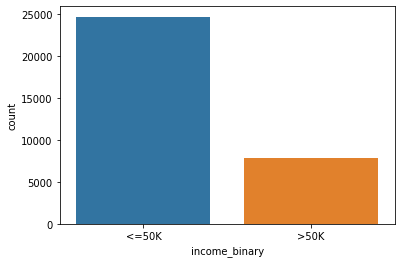

In [4]:
# plotting a bar chart to show class counts
plt.figure(figsize = (6,4))
sns.countplot(data=df, x='income_binary')

In [5]:
# Addressing class imbalance
# not using accuracy as an evaulation metric
# Precision and/or Recall or F1 Score

# AND
# using the class_weight='balanced' parameter to automatically 
# recalculates weights inversely proportional to class frequencies, 
# penalizing the tree heavily if it misclassifies the rare >50K income group

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [6]:
# YOUR CODE HERE
# inspecting DataFrame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [7]:
df.describe() # exploratory data analysis 

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


In [8]:
df.select_dtypes(include=['object'])

# NOTE: we want to transform categorical features

,workclass,education,marital-status,occupation,relationship,race,sex_selfID,native-country,income_binary
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Non-Female,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...
32556,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,United-States,<=50K
32557,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Non-Female,United-States,>50K
32558,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,United-States,<=50K
32559,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Non-Female,United-States,<=50K


In [9]:
all_features = df.columns.tolist()
all_features 

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex_selfID',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income_binary']

In [10]:
# checking for any NaN values
df.isnull().sum()

# NOT df.isnull().nunique()

# YES -> there is missing values

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

In [11]:
df.nunique()

age                  73
workclass             8
fnlwgt            21648
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex_selfID            2
capital-gain        106
capital-loss         92
hours-per-week       94
native-country       41
income_binary         2
dtype: int64

In [12]:
# checking for outliers
# looking at the feature with the highest anomaly count
numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_counts = {}

# check each column to count IQR outliers
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    iqr = q3-q1
    
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    
    # track count of values outside thresholds
    total_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_counts[col] = total_outliers

# extract the feature with the most outliers
target_feature = max(outlier_counts, key=outlier_counts.get)
print(f"Feature with most outliers: '{target_feature}' ({outlier_counts[target_feature]} outliers)")

Feature with most outliers: 'hours-per-week' (8913 outliers)


In [13]:
print(outlier_counts) # double-checking outlier counts

{'age': 143, 'fnlwgt': 992, 'education-num': 1198, 'capital-gain': 2712, 'capital-loss': 1519, 'hours-per-week': 8913}


### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

<Double click this Markdown cell to make it editable, and record your answers here.>

I found that the dataset contains missing values in several features such as age, workclass, occuptation, hours-per-week, and native-country. These features have important demographic and employement information that can contirbute to an income prediction. I'll handle missing values rather than removing the columns. I plan to impute rows with missing values because of the number of missing entries is somewhat small compared to the overall dataset size.
Another finding was that when I examined the distrubution of the target label, income_binary, I found class imbalance. There are significantly more individuals earning <=50K than individuals earning >50K. As a result,I want to avoid relying on only accuracy as an evaluation metric and focus on precision and recall with the F1 score. I plan to reduce bias toward the majority class by using the class_weight='balanced' parameter in my DecisionTree model. Another consideration was the fact that some of the features are categorical. Since ML models require numerical input, I'll apply one-hot encoding to transform these categorical vairables into numerical features. 
Moreover, I focused on hours-per-week to windsorize because it contained the largest number of IQR outliers. Since Decision Trees are generally robust to extreme values, I only winsorized this feature rather than transforming all numerical features.
Overall, I decided on a Decision Tree classifier because it can handle numerical and categorical feature after encoding, doens't require feature scaling, and is able to capture non-linear relationships. 



### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

<Double click this Markdown cell to make it editable, and record your answers here.>
1. 
The Census Income dataset was collected from the 1994 U.S. Census, so it may reflect historical biases and socioeconomic inequalities that existed at the time. Some features, such as race, sex_selfID, native-country, education, and occupation, could act as proxies for protected characteristics or socioeconomic status. As a result, the model may learn patterns that reflect existing disparities rather than true earning potential. If these biased patterns are used in decision-making, the model could unintentionally reinforce unfair treatment of certain demographic groups.

2. 
Individuals applying for financial products or services could be harmed if the model makes incorrect predictions. For example, a person whose income is incorrectly predicted to be above 50K may be denied financial assistance or low-interest loan programs they actually qualify for. Likewise, someone predicted to earn less than 50K when they actually earn more could receive recommendations or products that are not appropriate for their financial situation. Historically underrepresented groups, including women, racial minorities, immigrants, and lower-income individuals, may be at greater risk if the model reflects biases present in the training data. For this reason, the model should be used to support human decision-making rather than replace it, and it should be regularly evaluated for fairness across different demographic groups.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [14]:
# YOUR CODE HERE

In [15]:
# handling missing
# since there's NaN values we can remove them or replace them (imputation)
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# removing them
# df.dropna(axis=0, inplace=True) # dropping rows with NaN 

# imputation
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [16]:
df.nunique() # checking number of columns/features 

age                  73
workclass             8
fnlwgt            21648
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex_selfID            2
capital-gain        106
capital-loss         92
hours-per-week       94
native-country       41
income_binary         2
dtype: int64

In [17]:
# replacing outliers
import scipy.stats as stats

# winsorize (cap) the outliers for the feature with most outliers (hours-per-week)
df['hours-per-week-winsorized'] = stats.mstats.winsorize(df['hours-per-week'], limits=[0.01, 0.01])
df.head(15)

# drop 'hours-per-week' since we have a winsorized version
df = df.drop(columns=['hours-per-week'])


In [18]:
# one-hot encoding of income_binary
df['income_binary'] = df['income_binary'].map({'<=50K':0, ">50K":1})

# one-hot encoding of categorical features
#categorical_cols = df.select_dtypes(include='object').columns

categorical_cols = categorical_cols.drop('income_binary')

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [19]:
df.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,income_binary,hours-per-week-winsorized,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516,13,2174,0,0,40.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,83311,13,0,0,0,13.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38.0,215646,9,0,0,0,40.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,53.0,234721,7,0,0,0,40.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28.0,338409,13,0,0,0,40.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df.columns # checking columns/features

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'income_binary', 'hours-per-week-winsorized', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'education_11th', 'education_12th',
       'education_1st-4th', 'education_5th-6th', 'education_7th-8th',
       'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc',
       'education_Bachelors', 'education_Doctorate', 'education_HS-grad',
       'education_Masters', 'education_Preschool', 'education_Prof-school',
       'education_Some-college', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', '

In [22]:
len(df.columns) # 98 columns in total
# this includes the label, income_binary, which we'll remove 
# so 97 features in total

98

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

<Double click this Markdown cell to make it editable, and record your answers here.>

Handling Missing Values:
I handled missing values using imputation rather than removing rows. Numerical features were filled using the median value, while categorical features were filled using the most frequent category. I chose this approach because the missing values represented a relatively small portion of the dataset, and removing rows would unnecessarily reduce the amount of training data available.


Keep or Remove Certain Features:
I kept most features because demographic and employment information can contribute to predicting income. I focused on hours-per-week because it contained the largest number of outliers and created a winsorized version to reduce the influence of extreme values. I removed the original hours-per-week column after winsorizing to avoid duplicate information. I also converted categorical variables into numerical values using one-hot encoding so the model could process them.


Decision Tree Preparation Steps:
Since Decision Trees require numerical inputs, I converted the target label into binary values (0 and 1) and applied one-hot encoding to categorical features. Unlike KNN or Logistic Regression, Decision Trees do not require feature scaling because they make decisions based on feature splits rather than distances. Because the dataset contains class imbalance, I used class_weight='balanced' to reduce bias toward the majority class.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [23]:
# Create labeled examples from the dataset
# YOUR CODE HERE
y = df['income_binary']
X = df.drop(columns='income_binary')


In [24]:
# Create training and test sets out of the labeled examples 
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
# stratify because classes are imbalanced

In [26]:
# Train, test and evaluate your model
# YOUR CODE HERE

# Decision Tree
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# fit model
model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight='balanced', criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=42, splitter='best')

In [27]:
# making predictions
y_pred = model.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy:', accuracy)
print('F1 Score:', f1)

Accuracy: 0.8136035621065562
F1 Score: 0.6201501877346683


In [30]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE
max_depth = [5**i for i in range(0,5)]
msl = [2**i for i in range(-5,5)]
crits = ['gini', 'entropy']

param_grid = {
    'max_depth': max_depth,
    'min_samples_leaf': msl,
    'criterion': crits
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

#  best hyperparameters
grid.best_params_

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2}

In [31]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)

print("Best Accuracy:", best_accuracy)
print("Best F1:", best_f1)

Best Accuracy: 0.7977890373099954
Best F1: 0.6648002036141512


In [32]:
# Interpret your model's outputs 
# YOUR CODE HERE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                              Feature  Importance
29  marital-status_Married-civ-spouse    0.496295
2                       education-num    0.206585
3                        capital-gain    0.184410
0                                 age    0.069809
5           hours-per-week-winsorized    0.028721
4                        capital-loss    0.012954
10         workclass_Self-emp-not-inc    0.000598
48        relationship_Other-relative    0.000488
1                              fnlwgt    0.000141
8                   workclass_Private    0.000000


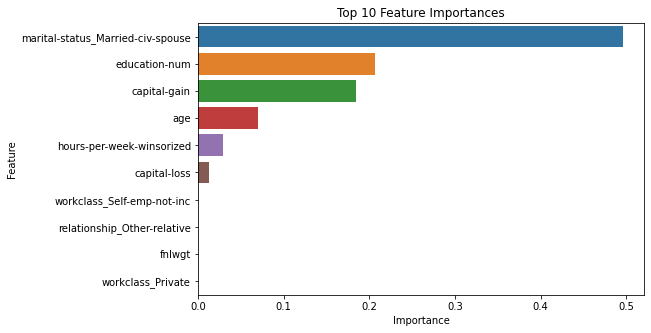

In [33]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Feature Importances")
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

<Double click this Markdown cell to make it editable, and record your answers here.>

1.
I chose a Decision Tree because it naturally handles both numerical and categorical data after encoding, captures non-linear relationships between demographic variables and income, and requires relatively little preprocessing compared to Logistic Regression or KNN.

2.
Grid Search showed that limiting tree depth and adjusting the minimum number of samples per leaf improved generalization by reducing overfitting. Rather than simply creating the deepest possible tree, tuning these hyperparameters produced a better balance between complexity and predictive performance.

3.
Feature importance measures how much each feature contributes to reducing classification error throughout the tree. Features with higher importance, such as education level, capital gain, age, or hours worked, have a greater influence on whether the model predicts that an individual's income exceeds 50K

4.
The dataset includes sensitive demographic variables such as race, sex, and native country. Even if these variables are removed, other features may act as proxies for protected characteristics. Incorrect predictions could unfairly affect individuals if the model were used for lending, financial assistance, or employment decisions, particularly for historically underrepresented groups. For this reason, the model should support, NOT REPLACE (don't overly on it), human decision-making and should be evaluated for fairness across demographic groups.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [34]:
from sklearn.compose import ColumnTransformer
# I only want to scale the continuous ones
# b/c the one-hot encoded columns are already 0/1 so they don't need scaling

# numerical features to scale
continuous_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week-winsorized'
]

# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()
preprocessor = ColumnTransformer(transformers=[('num', scaler, continuous_cols)], remainder='passthrough')
# Fit the scaler on the training data and transform the training data
X_train_scaled = preprocessor.fit_transform(X_train)
# Use the same scaler to transform the test data
X_test_scaled = preprocessor.transform(X_test)

In [ ]:
# I decided to go with only scaling the continuous variables
# continuous features can have vasltly different ranges 
# neural networks train much better when these features have similair cales
# one-hot encoded features are already standardized in a sense thta they only take values of 0 or 1

## Also, shoutout Thomas for pointing this out!!!


#### Original scaling provided in the notebook
# Scale your data for the neural network

# Create the scaler
##scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
##X_train_scaled = scaler.fit_transform(X_train)# YOUR CODE HERE)

# Use the same scaler to transform the test data
##X_test_scaled = scaler.transform(X_test)# YOUR CODE HERE)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [173]:
# adding a regularization 
# L2 Regularization
from tensorflow.keras import regularizers

# The model can learn simpler decision boundaries and
# hopefully the validation performance improves
# and overfitting is reduced

In [174]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1] # 97 features

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
# YOUR CODE HERE
input_layer = keras.layers.InputLayer(input_shape=(n_features,))
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
# YOUR CODE HERE
# regularization included
hidden_layer_1 = keras.layers.Dense(units=64, activation='relu', name='hidden_layer_1', kernel_regularizer=regularizers.l2(0.001))
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=32, activation='relu', name='hidden_layer_2', kernel_regularizer=regularizers.l2(0.001))
nn_model.add(hidden_layer_2)

# hidden_layer_3 = keras.layers.Dense(units=16, activation='relu', name='hidden_layer_3')
# nn_model.add(hidden_layer_3)


###### BRBRBRB
# I chose 2 hidden layers with decreasing numbers of neurons (64, 32)
# because the dataset contains 98 features and the model needs enough capacity
# to learn complex relationships while gradually reducing information.
# ReLU activation is used because it helps neural networks learn non-linear patterns
# and avoids some problems associated with sigmoid activation in hidden layers.


# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# YOUR CODE HERE
output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential_12"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
hidden_layer_1 (Dense)       (None, 64)                6272      
_________________________________________________________________
hidden_layer_2 (Dense)       (None, 32)                2080      
_________________________________________________________________
dense_12 (Dense)             (None, 1)                 33        
Total params: 8,385
Trainable params: 8,385
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [175]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)# YOUR CODE HERE


######
# I chose a learning rate of 0.01 because it provides a balance between
# learning speed and stability. A very large learning rate may cause the model
# to overshoot optimal weights, while a very small learning rate may train slowly.

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [176]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)# YOUR CODE HERE

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [177]:
# YOUR CODE HERE
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [178]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [179]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

num_epochs = 30# YOUR CODE HERE 
# I chose 30 epochs because the dataset is relatively large and the model
# needs enough iterations to learn patterns
# I tested out a few different numbers such as 100, 95, but the model seems to finish learning around epoch 25-30

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    validation_split=0.2,
    verbose=0, # disable the default progress bar
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)]
)# YOUR CODE HERE 

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 30], Loss: 0.4288, Accuracy: 0.8519, Val_loss: 0.4408, Val_accuracy: 0.8418
Epoch [10/ 30], Loss: 0.4068, Accuracy: 0.8583, Val_loss: 0.4222, Val_accuracy: 0.8503
Epoch [15/ 30], Loss: 0.3911, Accuracy: 0.8597, Val_loss: 0.4083, Val_accuracy: 0.8484
Epoch [20/ 30], Loss: 0.3790, Accuracy: 0.8601, Val_loss: 0.3962, Val_accuracy: 0.8497
Epoch [25/ 30], Loss: 0.3684, Accuracy: 0.8612, Val_loss: 0.3867, Val_accuracy: 0.8493
Epoch [30/ 30], Loss: 0.3594, Accuracy: 0.8614, Val_loss: 0.3796, Val_accuracy: 0.8497
Elapsed time: 32.34s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



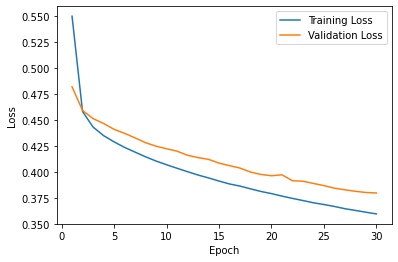

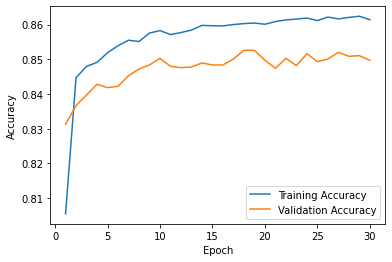

In [184]:
# Plot training loss and validation loss over epochs
# YOUR CODE HERE
plt.plot(range(1, num_epochs+1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
# YOUR CODE HERE
plt.plot(range(1, num_epochs+1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs+1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

For my own reference: 
IMPORTANT: remember to look at the scale on the axis
1. 
Most overfitting due to training too long
learning_rate=0.01
num_epochs=95
3 hidden layers 64-32-16 all with ReLU
and output layer unit-1 with sigmoid
Note that my model seems to learn about 25-30 epochs so I'll try 30 epochs, besides num_epochs, the other hyperparameters are the same as above
Epoch [95/ 95], Loss: 0.2617, Accuracy: 0.8796, Val_loss: 0.3359, Val_accuracy: 0.8424
Neural Network Accuracy: 0.852141870105942
Neural Network F1 Score: 0.6265994571539356

2. 
Better than #1, still some overfitting
learning_rate=0.01
num_epochs=30
3 hidden layers 64-32-16 all with ReLU
and output layer unit-1 with sigmoid
Reducing the number of epochs decreased overfitting, but there was still a noticeable gap between the training and validation metrics. I'll approach this by reducing my network size from 3 hidden layers to 2 hidden layers with units of 64 and 32
Epoch [30/ 30], Loss: 0.2920, Accuracy: 0.8654, Val_loss: 0.3179, Val_accuracy: 0.8474
Neural Network Accuracy: 0.8590511285122063
Neural Network F1 Score: 0.6594955489614243

3. 
Least overfitting, but slightly lower F1-score
learning_rate=0.01
num_epochs=30
2 hidden layers 64-32 all with ReLU
and output layer unit-1 with sigmoid
Not only did the amount of time it took to train went down, but there is significantly less overfitting! I'm happy with it, but I want to see if I can improve it even more.
Epoch [30/ 30], Loss: 0.2961, Accuracy: 0.8638, Val_loss: 0.3170, Val_accuracy: 0.8501
Neural Network Accuracy: 0.8599723629663749
Neural Network F1 Score: 0.6553287981859409

4. 
Smaller network underperformed on F1-score
I tried my neural network with units for the hidden layers 32-16 and it slightly improved accuracy, but decreased the F1 score while also showing slightly more overfitting.
Epoch [30/ 30], Loss: 0.2986, Accuracy: 0.8625, Val_loss: 0.3205, Val_accuracy: 0.8466
Neural Network Accuracy: 0.861200675571933
Neural Network F1 Score: 0.6517719568567026


5.
Highest F1-score, highest accuracy, best validation accuracy, but loss increased
Another idea: adding L2 regularization
learning_rate=0.01
num_epochs=30
2 hidden layers 64-32 all with ReLU
and output layer unit-1 with sigmoid
Epoch [30/ 30], Loss: 0.3594, Accuracy: 0.8614, Val_loss: 0.3796, Val_accuracy: 0.8497
Neural Network Accuracy: 0.8592046675879011
Neural Network F1 Score: 0.6988505747126437

This looks better when you click on the cell, but if you scroll down, there's a better formatted version.

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [186]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

# YOUR CODE HERE

# generate probabilities
nn_prob_predictions = nn_model.predict(X_test_scaled)

# convert probabilities into class labels
nn_class_label_predictions = []

for i in range(0, len(y_test)):
    if nn_prob_predictions[i] >= 0.5:
        nn_class_label_predictions.append(1)
    else:
        nn_class_label_predictions.append(0)

In [187]:
# Compute accuracy and F1 score for the neural network and print the results

# YOUR CODE HERE
# accuracy
nn_accuracy = accuracy_score(y_test, nn_class_label_predictions)

# F1 score
nn_f1 = f1_score(y_test, nn_class_label_predictions)

print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network F1 Score:", nn_f1)

Neural Network Accuracy: 0.8592046675879011
Neural Network F1 Score: 0.6988505747126437


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

<Double click this Markdown cell to make it editable, and record your answers here.>
1. 
I built a neural network with two hidden layers containing 64 and 32 neurons. Since the dataset contains 97 input features, I chose a larger first hidden layer to allow the model to learn complex relationships between demographic and employment features. The second hidden layer gradually reduces the number of neurons, allowing the network to learn more meaningful patterns while reducing unnecessary complexity.
I used ReLU activation functions in the hidden layers because ReLU allows neural networks to efficiently learn non-linear relationships while avoiding some issues associated with sigmoid activation functions in deeper networks. The output layer contains one neuron with a sigmoid activation function because this is a binary classification problem where the model predicts the probability of an individual earning >50k
I used stochastic gradient descent (SGD) with a learning rate of 0.01 because it provided a balance between training speed and stability. A learning rate that is too large can cause the model to overshoot optimal weights, while a learning rate that is too small can make training unnecessarily slow.
I trained the model for 30 epochs because testing showed that the model learned most patterns within approximately 25-30 epochs. Increasing the number of epochs beyond this point caused training accuracy to continue improving while validation performance stopped improving, which was a sign of overfitting.
I added L2 regularization to the hidden layers because it penalizes large weights and encourages the model to learn simpler patterns. This helped reduce overfitting and improved generalization on unseen data. Shoutout to Fardina who mentioned regularization at the end of the lab today!

2. The training curves showed how the model improved over time. If training accuracy continued increasing while validation accuracy stopped improving it would indicate overfitting. If both training and validation performance remained low that would be underfitting. 
The training curves showed that the model learned effectively without severe overfitting. Earlier experiments with more layers and more epochs showed a larger gap between training and validation performance, indicating overfitting. Reducing the network size from three hidden layers to two hidden layers and limiting training to 30 epochs reduced this gap.
Adding L2 regularization further improved generalization by preventing the model from relying too heavily on specific training examples. The final model had similar training and validation accuracy, suggesting that it learned useful patterns without memorizing the training data.

3. 
The final neural network achieved an accuracy of 0.8615 and an F1 score of 0.6988 on the test set.

Compared to the Decision Tree model, the neural network achieved better performance:

- Decision Tree Accuracy: 0.7978
- Neural Network Accuracy: 0.8592

- Decision Tree F1 Score: 0.6648
- Neural Network F1 Score: 0.6988



## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [188]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
# YOUR CODE HERE
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Decision Tree': [best_accuracy, best_f1],
    'Neural Network': [nn_accuracy, nn_f1]
})

print(results.to_string(index=False))

   Metric  Decision Tree  Neural Network
 Accuracy       0.797789        0.859205
 F1 Score       0.664800        0.698851


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

<Double click this Markdown cell to make it editable, and record your answers here.>

1.
The neural network performed slightly better than the Decision Tree model. The neural network achieved higher accuracy (0.8615 compared to 0.7978) and a slightly higher F1 score (0.6696 compared to 0.6648). The largest improvement was in accuracy, while F1 score only improved slightly. Since F1 score is more important for this problem due to class imbalance, the improvement suggests that the neural network was only marginally better at identifying the minority class.

2.
Although the neural network achieved better performance, the added complexity should be considered. Neural networks require additional preprocessing, including feature scaling, and are more difficult to interpret compared to Decision Trees. For this specific problem, the performance improvement may not fully justify the additional complexity because the F1 score improvement was small.

3.
If presenting this model to the company and client, I would recommend the neural network if maximizing predictive performance is the priority. However, I would also consider deploying the Decision Tree because it is easier to interpret and explain, especially in a financial context where understanding why a prediction was made is important. A hybrid approach could also be considered where the neural network provides predictions while the Decision Tree helps explain important factors influencing income predictions.

4.
If I had more time, I would try additional techniques to improve performance. For the neural network, I would experiment with different architectures, dropout layers, batch normalization, and different optimizers such as Adam (an optimizier I heard about today from Thomas).

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

<Double click this Markdown cell to make it editable, and record your answers here.>
1. I used it explain how one-hot encoding affects scaling and what it meant. In addition, I used it to help me think of ways to improve my model. It helped for the most part, but I definitely feel like it's more helpful to try explaining it to another person.

2. The part of the capstone that required the most effort was choosing. Choosing everything from the hyperparameters, features, the type methods I wanted to use to transform the features, what evaulation metric-basically everything needs some thinking in order to optimize the model. It's fun but very time-consuming. 

3. I checked for overfitting, underfitting, and all the numbers that were produced in my capstone and what they represented. I like seeing a high number for any type of evaulation metric, but it's important to make sure that it's not overfitting and that it's generalizing well.

4. Next time I would go to the moon room since I haven't tried them yet and maybe it'll help getting some independent time looking at the lab myself and then coming together as a group to discuss what ideas everybody had. The capstone spanned two labs so something I would do differently is ask the course support for help since it was a lot of content to go over.

**NOTE TO SELF** Remember to look at the scale of the axes when analyzing overfitting.

---

## 1. Most Overfitting: Training Too Long

**Observation:**  
The model appears to overfit because it was trained for too many epochs. The model seems to learn effectively around 25–30 epochs, so I will reduce the number of epochs while keeping the other hyperparameters the same.

**Hyperparameters:**
- Learning rate: 0.01
- Epochs: 95
- Architecture: 64-32-16
- Hidden layers: ReLU activation
- Output layer: 1 unit with sigmoid activation

**Training Results:**
- Loss: 0.2617
- Accuracy: 0.8796
- Validation Loss: 0.3359
- Validation Accuracy: 0.8424

**Test Results:**
- Neural Network Accuracy: 0.8521
- Neural Network F1 Score: 0.6266

**Conclusion:**  
Training for too many epochs caused the model to overfit, shown by the gap between training and validation performance.

---

## 2. Reduced Epochs: Less Overfitting, Still Some Overfitting

**Observation:**  
Reducing the number of epochs decreased overfitting, but there was still a noticeable gap between training and validation metrics. I will reduce the network size from three hidden layers to two hidden layers.

**Hyperparameters:**
- Learning rate: 0.01
- Epochs: 30
- Architecture: 64-32-16
- Hidden layers: ReLU activation
- Output layer: 1 unit with sigmoid activation

**Training Results:**
- Loss: 0.2920
- Accuracy: 0.8654
- Validation Loss: 0.3179
- Validation Accuracy: 0.8474

**Test Results:**
- Neural Network Accuracy: 0.8591
- Neural Network F1 Score: 0.6595

**Conclusion:**  
Reducing epochs improved generalization, but the model still showed some overfitting. The next step was reducing model complexity.

---

## 3. Least Overfitting: Reduced Network Size

**Observation:**  
Reducing the network from three hidden layers to two reduced overfitting and decreased training time. This produced a more balanced model, but I wanted to see if performance could be improved further.

**Hyperparameters:**
- Learning rate: 0.01
- Epochs: 30
- Architecture: 64-32
- Hidden layers: ReLU activation
- Output layer: 1 unit with sigmoid activation

**Training Results:**
- Loss: 0.2961
- Accuracy: 0.8638
- Validation Loss: 0.3170
- Validation Accuracy: 0.8501

**Test Results:**
- Neural Network Accuracy: 0.8600
- Neural Network F1 Score: 0.6553

**Conclusion:**  
This model showed the least overfitting and improved validation accuracy. However, the F1 score was slightly lower compared to Experiment 2.

---

## 4. Smaller Network: Lower F1 Score

**Observation:**  
I reduced the hidden layer sizes to 32-16. This slightly improved accuracy but decreased the F1 score and showed slightly more overfitting.

**Hyperparameters:**
- Learning rate: 0.01
- Epochs: 30
- Architecture: 32-16
- Hidden layers: ReLU activation
- Output layer: 1 unit with sigmoid activation

**Training Results:**
- Loss: 0.2986
- Accuracy: 0.8625
- Validation Loss: 0.3205
- Validation Accuracy: 0.8466

**Test Results:**
- Neural Network Accuracy: 0.8612
- Neural Network F1 Score: 0.6518

**Conclusion:**  
The smaller architecture slightly improved accuracy but reduced F1 score, suggesting the model lost some ability to correctly identify the positive class.

---

## 5. L2 Regularization: Best Overall Model

**Observation:**  
I added L2 regularization to reduce overfitting by penalizing large weights. This model achieved the highest F1 score and accuracy. The loss increased because the regularization penalty is included in the loss calculation.

**Hyperparameters:**
- Learning rate: 0.01
- Epochs: 30
- Architecture: 64-32
- Hidden layers: ReLU activation
- Output layer: 1 unit with sigmoid activation
- Added L2 regularization

**Training Results:**
- Loss: 0.3594
- Accuracy: 0.8614
- Validation Loss: 0.3796
- Validation Accuracy: 0.8497

**Test Results:**
- Neural Network Accuracy: 0.8592
- Neural Network F1 Score: 0.6988

**Conclusion:**  
Adding L2 regularization produced the best overall model. Although the loss increased due to the regularization penalty, the model achieved the highest F1 score and accuracy. Since the dataset is imbalanced, the improvement in F1 score indicates better generalization.

---

# Final Selected Model

**Architecture:**
- Learning rate: 0.01
- Epochs: 30
- Hidden layers: 64-32
- Activation: ReLU
- Output: Sigmoid
- Regularization: L2

**Final Performance:**
- Accuracy: 85.92%
- F1 Score: 69.89%